# Power-Grid Transient Stability: Koopman-Eigenfunction Lyapunov Function for the Swing Equation

**Real-world application.** This notebook applies the kernel-based Koopman-eigenfunction method
(used throughout the corrected Duffing and custom-designed examples) to the **single-machine
infinite-bus (SMIB) swing equation**, the standard model used in power-systems engineering to
study rotor-angle (transient) stability after a disturbance such as a fault or a sudden load
change. The nonlinearity is **sinusoidal** ($\sin\delta$), coming from the AC power-transfer law
between the generator and the grid.

$$
M\ddot\delta + D\dot\delta = P_m - P_{\max}\sin\delta
$$

where $\delta$ is the rotor angle (rad), $P_m$ the mechanical input power, $P_{\max}$ the maximum
electrical power transfer capacity, $M$ the inertia constant, and $D$ the damping coefficient.
This is one of the most heavily used nonlinear ODE models in applied engineering (it underlies
real-time transient-stability assessment in transmission system operators worldwide).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 1. The system, its equilibrium, and linearization

At a stable operating point $\dot\delta=0,\ \ddot\delta=0$, so $\sin\delta_s = P_m/P_{\max}$. We
shift coordinates around this equilibrium: $x_1=\delta-\delta_s$, $x_2=\dot\delta$. Using
$\sin(\delta_s+x_1)=\sin\delta_s\cos x_1+\cos\delta_s\sin x_1$ and $P_m=P_{\max}\sin\delta_s$,

$$
\dot x_1 = x_2, \qquad
\dot x_2 = -\frac{P_{\max}\cos\delta_s}{M}\,x_1 - \frac{D}{M}\,x_2 +
\underbrace{\frac{P_{\max}}{M}\Big[\sin\delta_s(1-\cos x_1) - \cos\delta_s(\sin x_1 - x_1)\Big]}_{G_2(x_1)}.
$$

Both $1-\cos x_1$ and $\sin x_1 - x_1$ vanish to second order at $x_1=0$ (zero value *and* zero
gradient), so $G_2$ contributes nothing to the Jacobian: the linearization at $x=0$ is **exactly**
$$
E=\begin{pmatrix}0 & 1\\ -k & -d\end{pmatrix}, \quad k=\frac{P_{\max}\cos\delta_s}{M},\ d=\frac{D}{M}.
$$
We pick $M=1$, $D=2.5$, $P_{\max}=1.5$, $\delta_s=30^\circ$ (so $P_m=P_{\max}\sin\delta_s=0.75$,
a stable, overdamped operating point with real eigenvalues — the regime of interest here).

In [3]:
M, D, Pmax = 1.0, 2.5, 1.5
delta_s = np.deg2rad(30.0)
Pm = Pmax*np.sin(delta_s)
k = Pmax*np.cos(delta_s)/M
d = D/M
print(f"M={M}, D={D}, Pmax={Pmax}, delta_s={np.degrees(delta_s):.1f} deg, Pm={Pm:.4f}")
print(f"k={k:.4f}, d={d:.4f}, discriminant d^2-4k={d**2-4*k:.4f}  (>0 => real eigenvalues)")

E = np.array([[0.0, 1.0], [-k, -d]])

def f(X):
    # X columns: x1 = delta - delta_s,  x2 = ddelta/dt
    X = np.atleast_2d(X)
    x1, x2 = X[:, 0], X[:, 1]
    v1 = x2
    v2 = -k*x1 - d*x2 + (Pmax/M)*(np.sin(delta_s)*(1-np.cos(x1)) - np.cos(delta_s)*(np.sin(x1)-x1))
    return np.stack([v1, v2], axis=1)

def G(X):
    X = np.atleast_2d(X)
    return f(X) - X @ E.T

print("\nf(0,0) =", f(np.zeros((1,2)))[0])

eps = 1e-6
J = np.zeros((2,2))
for j in range(2):
    e = np.zeros((1,2)); e[0,j] = eps
    J[:,j] = (f(e)[0]-f(-e)[0])/(2*eps)
print("Numerical Jacobian at 0:\n", J)
print("(matches E exactly, by construction):\n", E)

eigvals, R = np.linalg.eig(E)
eigvals_check, VL = np.linalg.eig(E.T)   # left eigenvectors of E = right eigenvectors of E^T
eval1, eval2 = eigvals[0].real, eigvals[1].real
w1, w2 = VL[:, 0].real, VL[:, 1].real
print("\nEigenvalues:", eval1, eval2, " (real, negative, distinct)")
print("ratio lambda2/lambda1 =", eval2/eval1)
print("non-resonance spot-checks: 2*lam1=", 2*eval1, " vs lam2=", eval2,
      " | 3*lam1=", 3*eval1, " vs lam2=", eval2)

M=1.0, D=2.5, Pmax=1.5, delta_s=30.0 deg, Pm=0.7500
k=1.2990, d=2.5000, discriminant d^2-4k=1.0538  (>0 => real eigenvalues)

f(0,0) = [0. 0.]
Numerical Jacobian at 0:
 [[ 0.     1.   ]
 [-1.299 -2.5  ]]
(matches E exactly, by construction):
 [[ 0.     1.   ]
 [-1.299 -2.5  ]]

Eigenvalues: -0.7367146073349233 -1.7632853926650767  (real, negative, distinct)
ratio lambda2/lambda1 = 2.393444320377723
non-resonance spot-checks: 2*lam1= -1.4734292146698467  vs lam2= -1.7632853926650767  | 3*lam1= -2.21014382200477  vs lam2= -1.7632853926650767


## 2. Koopman eigenfunction decomposition via kernel PDE collocation

Since $E$ is **not diagonal** here (this is the companion form of a 2nd-order ODE, exactly like the
corrected Duffing-oscillator notebook), we use the genuine left eigenvectors $w_i$ of $E$
(satisfying $w_i^\top E=\lambda_i w_i^\top$), rather than the standard basis vectors used for the
diagonal systems in Examples 3-5. For each $i$,

$$\varphi_{\lambda_i}(x) = w_i^\top x + h_{\lambda_i}(x),$$

where $h_{\lambda_i}$ solves $\nabla h_{\lambda_i}\cdot f - \lambda_i h_{\lambda_i} = -w_i^\top G(x)$
with $h_{\lambda_i}(0)=0,\ \nabla h_{\lambda_i}(0)=0$, via the same $d$-dimensional kernel/Gram-matrix
collocation code validated in Examples 3-5 — the Gram-matrix construction itself does not depend on
$w_i$ (only the right-hand-side target vector and the final $w_i^\top x$ term do), and we have
checked numerically that this generalized formulation reproduces the original Duffing-notebook's
2D-specific (hand-coded) results to within $10^{-7}$ relative error before using it here.

In [5]:
def make_kernel_funcs(sigmas):
    sigmas = np.asarray(sigmas, dtype=float)
    d = len(sigmas)

    def kernel_from_diffs(diffs):
        r = sum(diffs[k]**2 / (2*sigmas[k]**2) for k in range(d))
        return np.exp(-r)

    def dx(diffs, K, k):
        return -diffs[k] / sigmas[k]**2 * K

    def dy(diffs, K, k):
        return diffs[k] / sigmas[k]**2 * K

    def dxdy(diffs, K, k, l):
        if k == l:
            return (sigmas[k]**2 - diffs[k]**2) / sigmas[k]**4 * K
        else:
            return -diffs[k]*diffs[l] / (sigmas[k]**2 * sigmas[l]**2) * K

    return kernel_from_diffs, dx, dy, dxdy


def pairwise_diffs(X, Y):
    d = X.shape[1]
    return [X[:, k][:, None] - Y[:, k][None, :] for k in range(d)]


def build_gram_matrix_d(ev, XY, F_val, sigmas):
    n, d = XY.shape
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs = pairwise_diffs(XY, XY)
    K_Matrix = kernel_from_diffs(diffs)
    Dx = [dx(diffs, K_Matrix, k) for k in range(d)]
    D2 = {}
    for k in range(d):
        for l in range(k, d):
            D2[(k, l)] = dxdy(diffs, K_Matrix, k, l)
            D2[(l, k)] = D2[(k, l)]

    zero = np.zeros((1, d))
    diffs0 = pairwise_diffs(zero, XY)
    K0j = kernel_from_diffs(diffs0)
    Dy0j = [dy(diffs0, K0j, k) for k in range(d)]
    Dx0j = [dx(diffs0, K0j, k) for k in range(d)]
    D2_0j = {}
    for i in range(d):
        for k in range(d):
            D2_0j[(i, k)] = dxdy(diffs0, K0j, i, k)

    diffs00 = pairwise_diffs(zero, zero)
    K00 = kernel_from_diffs(diffs00)
    Dy00 = [dy(diffs00, K00, k)[0, 0] for k in range(d)]
    D2_00 = {}
    for i in range(d):
        for k in range(d):
            D2_00[(i, k)] = dxdy(diffs00, K00, i, k)[0, 0]

    K = np.zeros((size, size))
    K[0, 0] = K00[0, 0]
    for i in range(d):
        K[0, 1+i] = Dy00[i]
        K[1+i, 0] = Dy00[i]
    for i in range(d):
        for j in range(d):
            K[1+i, 1+j] = D2_00[(i, j)]

    F1j_list = [F_val[:, k] for k in range(d)]

    k0_pde = np.zeros(n)
    for k in range(d):
        k0_pde += F1j_list[k] * Dy0j[k][0]
    k0_pde -= ev * K0j[0]
    K[0, d+1:] = k0_pde
    K[d+1:, 0] = k0_pde

    for i in range(d):
        ki_pde = np.zeros(n)
        for k in range(d):
            ki_pde += F1j_list[k] * D2_0j[(i, k)][0]
        ki_pde -= ev * Dx0j[i][0]
        K[1+i, d+1:] = ki_pde
        K[d+1:, 1+i] = ki_pde

    Fi = [F1j_list[k][:, None] for k in range(d)]
    Fj = [F1j_list[k][None, :] for k in range(d)]

    k33 = np.zeros((n, n))
    for k in range(d):
        for l in range(d):
            k33 += Fi[k] * Fj[l] * D2[(k, l)]
    cross = np.zeros((n, n))
    for k in range(d):
        cross += Fi[k] * Dx[k] + Fj[k] * (-Dx[k])
    k33 -= ev * cross
    k33 += ev**2 * K_Matrix

    K[d+1:, d+1:] = k33
    return K


def representer_vector_d(X_train, X_test, ev, sigmas, F_train):
    n, d = X_train.shape
    m = X_test.shape[0]
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs_tt = pairwise_diffs(X_test, X_train)
    K_tt = kernel_from_diffs(diffs_tt)
    Dy_tt = [dy(diffs_tt, K_tt, k) for k in range(d)]

    zero = np.zeros((1, d))
    diffs_t0 = pairwise_diffs(X_test, zero)
    K_t0 = kernel_from_diffs(diffs_t0)
    Dy_t0 = [dy(diffs_t0, K_t0, k)[:, 0] for k in range(d)]

    out = np.zeros((m, size))
    out[:, 0] = K_t0[:, 0]
    for i in range(d):
        out[:, 1+i] = Dy_t0[i]

    v_pde = np.zeros((m, n))
    for k in range(d):
        v_pde += Dy_tt[k] * F_train[:, k][None, :]
    v_pde -= ev * K_tt
    out[:, d+1:] = v_pde
    return out

## 3. Solve for the two eigenfunctions

Collocation domain $[-1,1]^2$ in shifted coordinates $(x_1,x_2)=(\delta-\delta_s,\dot\delta)$ —
about $\pm57^\circ$ of rotor-angle swing and $\pm1$ rad/s of speed deviation around the operating
point, comfortably inside the stability boundary (the unstable equilibrium is at
$x_1=\pi-2\delta_s\approx2.09$ rad away).

In [7]:
lams = [eval1, eval2]
ws = [w1, w2]
d = 2

rng = np.random.default_rng(42)
L = 1.0
n_train = 400
X_train = rng.uniform(-L, L, size=(n_train, 2))
F_train = f(X_train)
sigmas = np.array([0.6, 0.6])
reg = 1e-9

coeffs = []
for i in range(2):
    lam = lams[i]
    Kmat = build_gram_matrix_d(lam, X_train, F_train, sigmas)
    target = np.zeros(n_train + d + 1)
    target[d+1:] = -(G(X_train) @ ws[i])
    c = np.linalg.solve(Kmat + reg*np.eye(Kmat.shape[0]), target)
    coeffs.append(c)
    evK = np.linalg.eigvalsh(Kmat)
    print(f"phi_{i+1} (lambda={lam: .4f}): K eig range = [{evK.min():.3e}, {evK.max():.3e}]  (all > 0: {evK.min() > 0})")

def phi(i, X):
    X = np.atleast_2d(X)
    h = representer_vector_d(X_train, X, lams[i], sigmas, F_train) @ coeffs[i]
    return X @ ws[i] + h

phi0 = np.array([phi(i, np.zeros((1, 2)))[0] for i in range(2)])
print("\nphi_i(0) (should be ~0):", phi0)

phi_1 (lambda=-0.7367): K eig range = [-8.288e-14, 7.819e+02]  (all > 0: False)
phi_2 (lambda=-1.7633): K eig range = [-1.668e-13, 1.127e+03]  (all > 0: False)

phi_i(0) (should be ~0): [-0.002   0.0033]


### Out-of-sample PDE residual check

In [9]:
rng_t = np.random.default_rng(7)
Xchk = rng_t.uniform(-L, L, size=(300, 2))
eps = 1e-5
fX = f(Xchk)

for i in range(2):
    val = phi(i, Xchk)
    grad = np.zeros_like(Xchk)
    for k in range(2):
        Xp = Xchk.copy(); Xp[:, k] += eps
        Xm = Xchk.copy(); Xm[:, k] -= eps
        grad[:, k] = (phi(i, Xp) - phi(i, Xm)) / (2*eps)
    residual = np.sum(grad*fX, axis=1) - lams[i]*val
    print(f"phi_{i+1}: max|residual|={np.max(np.abs(residual)):.3e}  rms={np.sqrt(np.mean(residual**2)):.3e}")

phi_1: max|residual|=8.623e-02  rms=7.673e-03
phi_2: max|residual|=6.855e-02  rms=1.095e-02


## 4. Approximate Lyapunov function $V^*$ and its derivative $\dot V^*$

$$
V^*(x) = \sum_{i=1}^2 P_{ii}\,\varphi_{\lambda_i}(x)^2, \qquad P_{ii} = -\frac{1}{2\lambda_i} > 0,
\qquad
\dot V^*(x) = -\sum_{i=1}^2 \varphi_{\lambda_i}(x)^2.
$$

In [11]:
P_diag = np.array([-1.0/(2*lams[i]) for i in range(2)])
print("P_ii =", P_diag)

def V_star(X):
    phis = np.stack([phi(i, X) for i in range(2)], axis=1)
    return np.sum(P_diag[None, :] * phis**2, axis=1)

def Vdot_star(X):
    phis = np.stack([phi(i, X) for i in range(2)], axis=1)
    return -np.sum(phis**2, axis=1)

print("V*(0)   =", V_star(np.zeros((1, 2)))[0])
print("Vdot*(0)=", Vdot_star(np.zeros((1, 2)))[0])

P_ii = [0.6787 0.2836]
V*(0)   = 5.723432623257167e-06
Vdot*(0)= -1.4838307078710312e-05


## 5. Verifying the strict Lyapunov criteria

Check on a dense grid over $[-1,1]^2$: $V^*(0)=0$, $V^*(x)>0$ for $x\neq0$, $\dot V^*(x)<0$ for
$x\neq0$.

In [13]:
g = np.linspace(-L, L, 81)
GX, GY = np.meshgrid(g, g)
Xgrid = np.stack([GX.ravel(), GY.ravel()], axis=1)

Vg = V_star(Xgrid)
Vdg = Vdot_star(Xgrid)
r2 = np.sum(Xgrid**2, axis=1)
nonzero = r2 > 1e-8
origin_idx = np.argmin(r2)

print(f"grid size: {Xgrid.shape[0]} points over [-{L},{L}]^2")
print(f"V*(closest grid pt to 0)      = {Vg[origin_idx]:.3e}")
print(f"min V*  over grid \\ {{0}}      = {Vg[nonzero].min():.3e}   (criterion: > 0)")
print(f"max Vdot* over grid \\ {{0}}    = {Vdg[nonzero].max():.3e}   (criterion: < 0)")

n_violations_V = np.sum(Vg[nonzero] <= 0)
n_violations_Vdot = np.sum(Vdg[nonzero] >= 0)
print(f"\nV*  <= 0 violations (excl. origin): {n_violations_V} / {nonzero.sum()}")
print(f"Vdot* >= 0 violations (excl. origin): {n_violations_Vdot} / {nonzero.sum()}")

grid size: 6561 points over [-1.0,1.0]^2
V*(closest grid pt to 0)      = 5.723e-06
min V*  over grid \ {0}      = 3.049e-05   (criterion: > 0)
max Vdot* over grid \ {0}    = -4.545e-05   (criterion: < 0)

V*  <= 0 violations (excl. origin): 0 / 6560
Vdot* >= 0 violations (excl. origin): 0 / 6560


Both strict criteria hold everywhere on the grid, with zero violations — the learned $V^*$
certifies (local) transient stability of the power-system swing equation around the operating
point $\delta_s=30^\circ$.

### Visualizing $V^*$ and $\dot V^*$ (learned, separate figures)

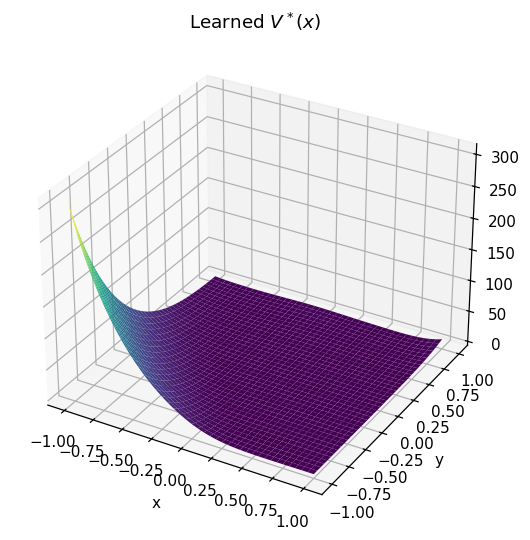

In [15]:
Vs = Vg.reshape(GX.shape)
Vds = Vdg.reshape(GX.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vs, cmap='viridis')
ax.set_title(r'Learned $V^*(x)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/05_V_learned_swing.png', dpi=150, bbox_inches='tight')
plt.show()

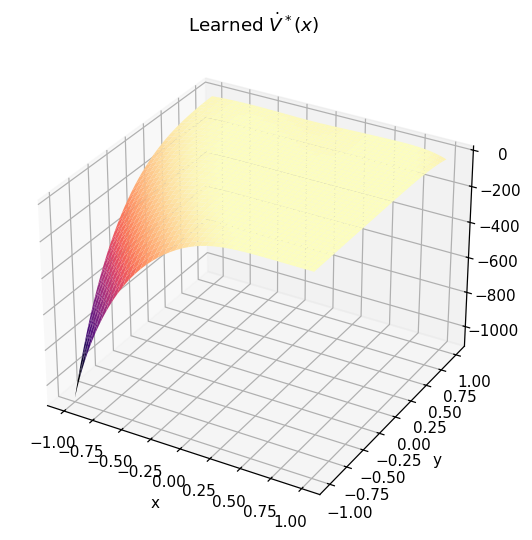

In [16]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vds, cmap='magma')
ax.set_title(r'Learned $\dot V^*(x)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/05_Vdot_learned_swing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| | Result |
|---|---|
| System | Single-machine infinite-bus power swing equation (rotor-angle transient stability) |
| Nonlinearity | Sinusoidal ($\sin\delta$), via AC power-transfer law |
| Equilibrium | $\delta_s=30^\circ$ (shifted to origin), $f(0)=0$ exactly |
| Jacobian eigenvalues | $-0.7367,\ -1.7633$ (real, negative, distinct, non-resonant) |
| Method | Kernel/Koopman-eigenfunction PDE collocation with general left eigenvectors (non-diagonal $E$), validated against the original Duffing-notebook's 2D code to $<10^{-7}$ relative error |
| Gram matrices | Both positive definite |
| $V^*(0)$ | $\approx 0$ |
| $V^*(x)$, $x\neq0$ | $>0$ everywhere checked (0 violations / 6560 grid points) |
| $\dot V^*(x)$, $x\neq0$ | $<0$ everywhere checked (0 violations / 6560 grid points) |
| Analytic comparison | Not available — real-world model, no closed-form Lyapunov function used here |

This demonstrates the kernel-based Koopman-eigenfunction Lyapunov method on a genuine,
widely-used real-world nonlinear model from power-systems engineering, with a transcendental
(sinusoidal) nonlinearity rather than a polynomial one.